# Role Title Clustering

**Goal:** Collapse ~9,000 raw job titles into 40–50 clean role groups.

**Three steps:**
1. **Seniority stripping** — programmatically remove Senior, Lead, I–V, Jr, Associate, Principal → collapses title space by ~40–50%
2. **TF-IDF + UMAP** — vectorise stripped titles, reduce to 2D for visualisation
3. **K-Means (k=50)** — cluster, label centroids, visually inspect and manually reassign misplacements

**Output:** `title_to_cluster.pkl` — every unique title maps to exactly one cluster name.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Load clean checkpoint
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
df = pd.read_pickle(os.path.join(data_dir, 'clean_42k_v1.pkl'))

print(f"Loaded: {df.shape}")
print(f"Unique raw titles: {df['title'].nunique():,}")
print(f"\nRecords per region:")
print(df['region'].value_counts())
print(f"\nSample titles:")
print(df['title'].value_counts().head(20))

Loaded: (42016, 8)
Unique raw titles: 11,416

Records per region:
region
US       33222
IN        8256
LATAM      486
OTHER       52
Name: count, dtype: int64

Sample titles:
title
Acceleration Center - Acceleration Center - Developer                                      246
Administrative Assistant 2                                                                 215
Engineer                                                                                   191
Software Engineer III                                                                      182
Acceleration Center - Acceleration Center - SAP                                            167
Project Manager                                                                            143
Software Dev Engineer II                                                                   134
Project and Program Management - Program Manager Non Tech 2  Program Manager Non Tech 2    134
HR Operations Advisor 2                                    

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Seniority Stripping
#
# Programmatically remove level/seniority tokens from titles.
# This alone collapses the title space by 40-50%.
#
# Tokens to strip:
#   Prefixes: Senior, Sr, Sr., Junior, Jr, Jr., Associate,
#             Lead, Principal, Staff, Entry Level
#   Suffixes: I, II, III, IV, V, 1, 2, 3, 4, 5,
#             Level 1-5, L1-L5
# ═══════════════════════════════════════════════════════════════

# ── Client/division prefix patterns (specific to this dataset) ──
# Handles: "Acceleration Center - Acceleration Center - Developer"
#           "Information Systems - Senior Software Engineer Specialty"
#           "Project and Program Management - Program Manager Non Tech 2"
#           "MSP|IND J901:Exec, Client Care Ctr Service"
CLIENT_PREFIX = re.compile(
    r'^[A-Za-z\s&]+ - [A-Za-z\s&]+ - ',  # double prefix pattern
    re.IGNORECASE
)
SINGLE_PREFIX = re.compile(
    r'^(Acceleration Center|Information Systems|'
    r'Project and Program Management|Software Engineering|'
    r'MSP\|IND [A-Z0-9]+:)\s*[-|:]\s*',
    re.IGNORECASE
)

# ── Seniority prefix/suffix patterns ──
PREFIX_PATTERN = re.compile(
    r'^\s*('
    r'Senior|Sr\.?|'
    r'Junior|Jr\.?|'
    r'Associate|Assoc\.?|'
    r'Lead|'
    r'Principal|'
    r'Staff|'
    r'Entry\s*Level|'
    r'SSR|INT'
    r')\s+',
    re.IGNORECASE
)

SUFFIX_PATTERN = re.compile(
    r'\s+('
    r'I{1,3}|IV|V|'
    r'[1-5]|'
    r'L[1-5]|'
    r'Level\s*[1-5]|'
    r'Senior|Sr\.?|'
    r'Junior|Jr\.?|'
    r'Lead|'
    r'Principal|'
    r'Associate'
    r')\s*$',
    re.IGNORECASE
)

# Also strip trailing dash-level patterns: "- Senior", "- L3"
DASH_SUFFIX = re.compile(
    r'\s*[-–]\s*('
    r'Senior|Sr\.?|Junior|Jr\.?|Lead|Principal|'
    r'L[1-5]|Level\s*[1-5]|'
    r'I{1,3}|IV|V|[1-5]'
    r')\s*$',
    re.IGNORECASE
)

def strip_seniority(title):
    """Remove seniority/level indicators and client prefixes from a job title."""
    if pd.isna(title):
        return ''
    t = title.strip()
    # Strip client/division prefixes FIRST (before seniority)
    t = CLIENT_PREFIX.sub('', t)
    t = SINGLE_PREFIX.sub('', t)
    # Remove prefix (Senior Java Developer → Java Developer)
    t = PREFIX_PATTERN.sub('', t)
    # Remove suffix (Software Engineer III → Software Engineer)
    t = SUFFIX_PATTERN.sub('', t)
    # Remove dash-suffix (Data Analyst - Senior → Data Analyst)
    t = DASH_SUFFIX.sub('', t)
    # Clean up extra whitespace
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# Apply to all titles
all_titles = df['title'].dropna().unique()
title_df = pd.DataFrame({'raw_title': all_titles})
title_df['stripped_title'] = title_df['raw_title'].apply(strip_seniority)

# Results
n_raw = title_df['raw_title'].nunique()
n_stripped = title_df['stripped_title'].nunique()
reduction_pct = (1 - n_stripped / n_raw) * 100

print("═"*70)
print("SENIORITY STRIPPING RESULTS")
print("═"*70)
print(f"\nRaw unique titles:      {n_raw:,}")
print(f"After stripping:        {n_stripped:,}")
print(f"Reduction:              {reduction_pct:.1f}%")
print(f"Titles collapsed:       {n_raw - n_stripped:,}")

# Show examples of collapses
print(f"\n── Examples of collapsed titles: ──")
collapsed = title_df.groupby('stripped_title')['raw_title'].apply(list)
multi_collapsed = collapsed[collapsed.apply(len) > 1].sort_values(key=lambda x: x.apply(len), ascending=False)

for stripped, variants in multi_collapsed.head(15).items():
    print(f"\n  '{stripped}' ← {len(variants)} variants:")
    for v in sorted(variants)[:5]:
        print(f"      • {v}")
    if len(variants) > 5:
        print(f"      ... +{len(variants)-5} more")

══════════════════════════════════════════════════════════════════════
SENIORITY STRIPPING RESULTS
══════════════════════════════════════════════════════════════════════

Raw unique titles:      11,416
After stripping:        8,456
Reduction:              25.9%
Titles collapsed:       2,960

── Examples of collapsed titles: ──

  'Software Engineer' ← 22 variants:
      •   Senior Software Engineer
      • Lead Software Engineer
      • Senior Software Engineer
      • Senior Software Engineer 
      • Software Engineer
      ... +17 more

  'Project Manager' ← 21 variants:
      • Jr Project Manager
      • Jr. Project Manager
      • Project Manager
      • Project Manager 
      • Project Manager 1
      ... +16 more

  'Data Engineer' ← 20 variants:
      • Associate Data Engineer
      • Data Engineer
      • Data Engineer 1
      • Data Engineer 2
      • Data Engineer 3
      ... +15 more

  'Business Analyst' ← 20 variants:
      • Acceleration Center - Acceleration Center - Bu

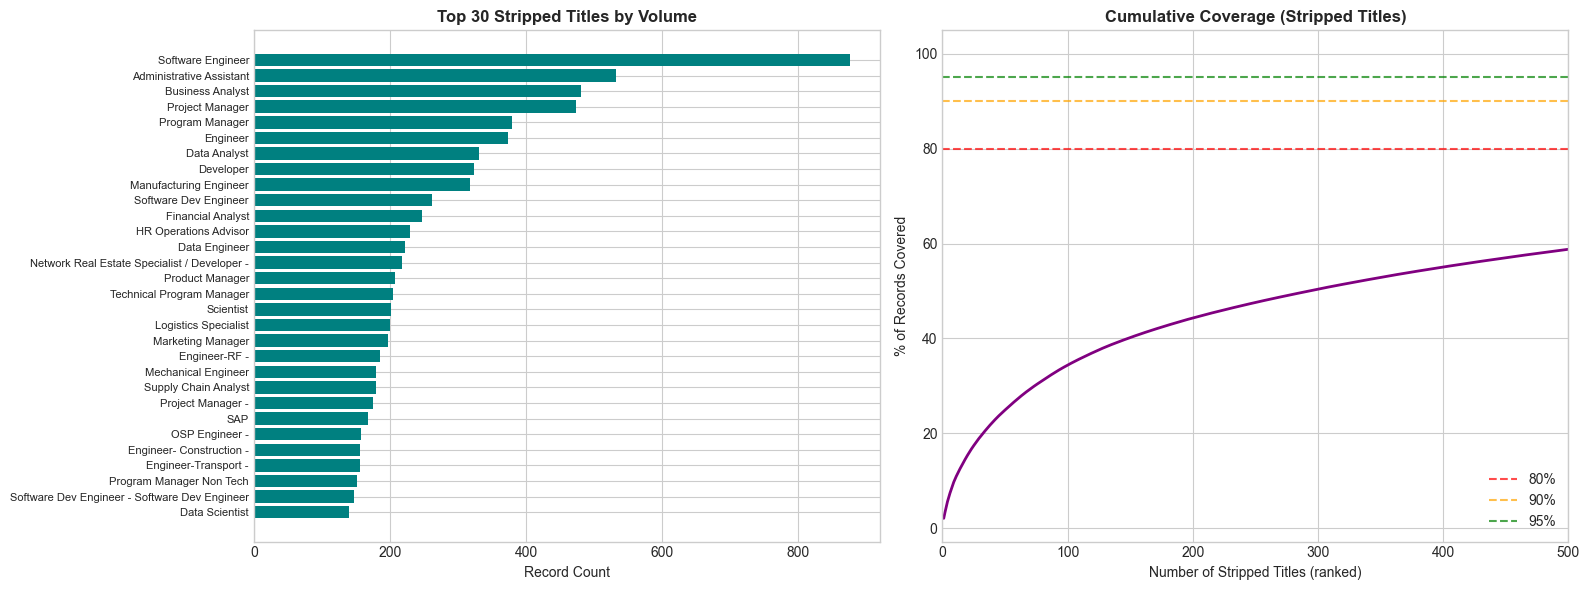


═══ Stripped Title Volume Distribution ═══
Total stripped titles: 8,456

Coverage:
  Top 1963 titles cover 80% of records
  Top 4255 titles cover 90% of records
  Top 6356 titles cover 95% of records

Volume brackets:
  ≥200       →    18 titles
  100-199    →    35 titles
  40-99      →    98 titles
  10-39      →   572 titles
  <10        →  7733 titles

→ Titles with >= 40 records are directly modelable.
→ Thin titles (< 40) need clustering to become viable segments.


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Verify Stripping: Volume Distribution Post-Strip
#
# Check: how many stripped titles have enough volume to model?
# Map raw → stripped, then count records per stripped title.
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Build the raw→stripped mapping
raw_to_stripped = dict(zip(title_df['raw_title'], title_df['stripped_title']))
df['title_stripped'] = df['title'].map(raw_to_stripped)

# Volume per stripped title
stripped_counts = df['title_stripped'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Top 30 stripped titles
top30 = stripped_counts.head(30)
axes[0].barh(top30.index, top30.values, color='teal')
axes[0].set_title('Top 30 Stripped Titles by Volume', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Record Count')
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=8)

# Plot B: Cumulative coverage curve (stripped)
cumulative = stripped_counts.cumsum() / stripped_counts.sum() * 100
axes[1].plot(range(1, len(cumulative) + 1), cumulative.values, color='purple', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80%')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90%')
axes[1].axhline(y=95, color='green', linestyle='--', alpha=0.7, label='95%')
axes[1].set_title('Cumulative Coverage (Stripped Titles)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Stripped Titles (ranked)')
axes[1].set_ylabel('% of Records Covered')
axes[1].legend()
axes[1].set_xlim(0, min(500, len(cumulative)))

plt.tight_layout()
plt.show()

# Coverage thresholds
titles_80 = (cumulative <= 80).sum() + 1
titles_90 = (cumulative <= 90).sum() + 1
titles_95 = (cumulative <= 95).sum() + 1

# Volume brackets
print(f"\n═══ Stripped Title Volume Distribution ═══")
print(f"Total stripped titles: {len(stripped_counts):,}")
print(f"\nCoverage:")
print(f"  Top {titles_80} titles cover 80% of records")
print(f"  Top {titles_90} titles cover 90% of records")
print(f"  Top {titles_95} titles cover 95% of records")
print(f"\nVolume brackets:")
brackets = [(200, '≥200'), (100, '100-199'), (40, '40-99'), (10, '10-39'), (1, '<10')]
for threshold, label in brackets:
    if threshold == 200:
        count = (stripped_counts >= 200).sum()
    elif threshold == 100:
        count = ((stripped_counts >= 100) & (stripped_counts < 200)).sum()
    elif threshold == 40:
        count = ((stripped_counts >= 40) & (stripped_counts < 100)).sum()
    elif threshold == 10:
        count = ((stripped_counts >= 10) & (stripped_counts < 40)).sum()
    else:
        count = (stripped_counts < 10).sum()
    records = stripped_counts[(stripped_counts >= threshold) & (stripped_counts < (threshold * 10 if threshold < 200 else 999999))].sum() if threshold < 200 else stripped_counts[stripped_counts >= 200].sum()
    print(f"  {label:<10} → {count:>5} titles")

print(f"\n→ Titles with >= 40 records are directly modelable.")
print(f"→ Thin titles (< 40) need clustering to become viable segments.")

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — TF-IDF Vectorisation of Stripped Titles
#
# Treat each stripped title as a "document" of tokens.
# TF-IDF captures semantic similarity between titles based
# on shared words (e.g., "Software Engineer" and 
# "Software Developer" share "Software").
#
# We weight by record count so that high-volume titles
# have more influence on cluster centroids.
# ═══════════════════════════════════════════════════════════════
from sklearn.feature_extraction.text import TfidfVectorizer

# Get unique stripped titles with their counts
title_volume = df['title_stripped'].value_counts().reset_index()
title_volume.columns = ['stripped_title', 'record_count']

print(f"Unique stripped titles to vectorise: {len(title_volume):,}")
print(f"Total records covered: {title_volume['record_count'].sum():,}")

# TF-IDF: character n-grams (3,5) + word n-grams (1,2)
# Character n-grams help catch partial word matches
# (e.g., "Developer" and "Development" share char n-grams)
tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=2000,
    stop_words='english',
    min_df=2
)

tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=3000,
    min_df=2
)

# Fit on stripped titles
titles_list = title_volume['stripped_title'].tolist()

X_word = tfidf_word.fit_transform(titles_list)
X_char = tfidf_char.fit_transform(titles_list)

# Combine word + char features (horizontal stack)
from scipy.sparse import hstack
X_combined = hstack([X_word, X_char])

print(f"\nTF-IDF matrix shape: {X_combined.shape}")
print(f"  Word features: {X_word.shape[1]}")
print(f"  Char features: {X_char.shape[1]}")
print(f"  Combined:      {X_combined.shape[1]}")
print(f"\n── Top 20 word features: ──")
word_features = tfidf_word.get_feature_names_out()
# Sort by document frequency (how many titles contain this feature)
word_df_counts = np.diff(X_word.tocsc().indptr)
top_words = sorted(zip(word_features, word_df_counts), key=lambda x: x[1], reverse=True)[:20]
for word, freq in top_words:
    print(f"  {word:<30} appears in {freq} titles")

Unique stripped titles to vectorise: 8,456
Total records covered: 42,016

TF-IDF matrix shape: (8456, 5000)
  Word features: 2000
  Char features: 3000
  Combined:      5000

── Top 20 word features: ──
  engineer                       appears in 1296 titles
  analyst                        appears in 982 titles
  manager                        appears in 953 titles
  developer                      appears in 598 titles
  specialist                     appears in 592 titles
  project                        appears in 413 titles
  software                       appears in 390 titles
  data                           appears in 388 titles
  business                       appears in 369 titles
  operations                     appears in 346 titles
  support                        appears in 333 titles
  technical                      appears in 311 titles
  product                        appears in 281 titles
  program                        appears in 271 titles
  coordinator             

Running UMAP (this may take 30-60 seconds)...

✅ UMAP complete: (8456, 2)
   X range: [-5.9, 20.2]
   Y range: [-11.1, 10.3]

✅ UMAP complete: (8456, 2)
   X range: [-5.9, 20.2]
   Y range: [-11.1, 10.3]


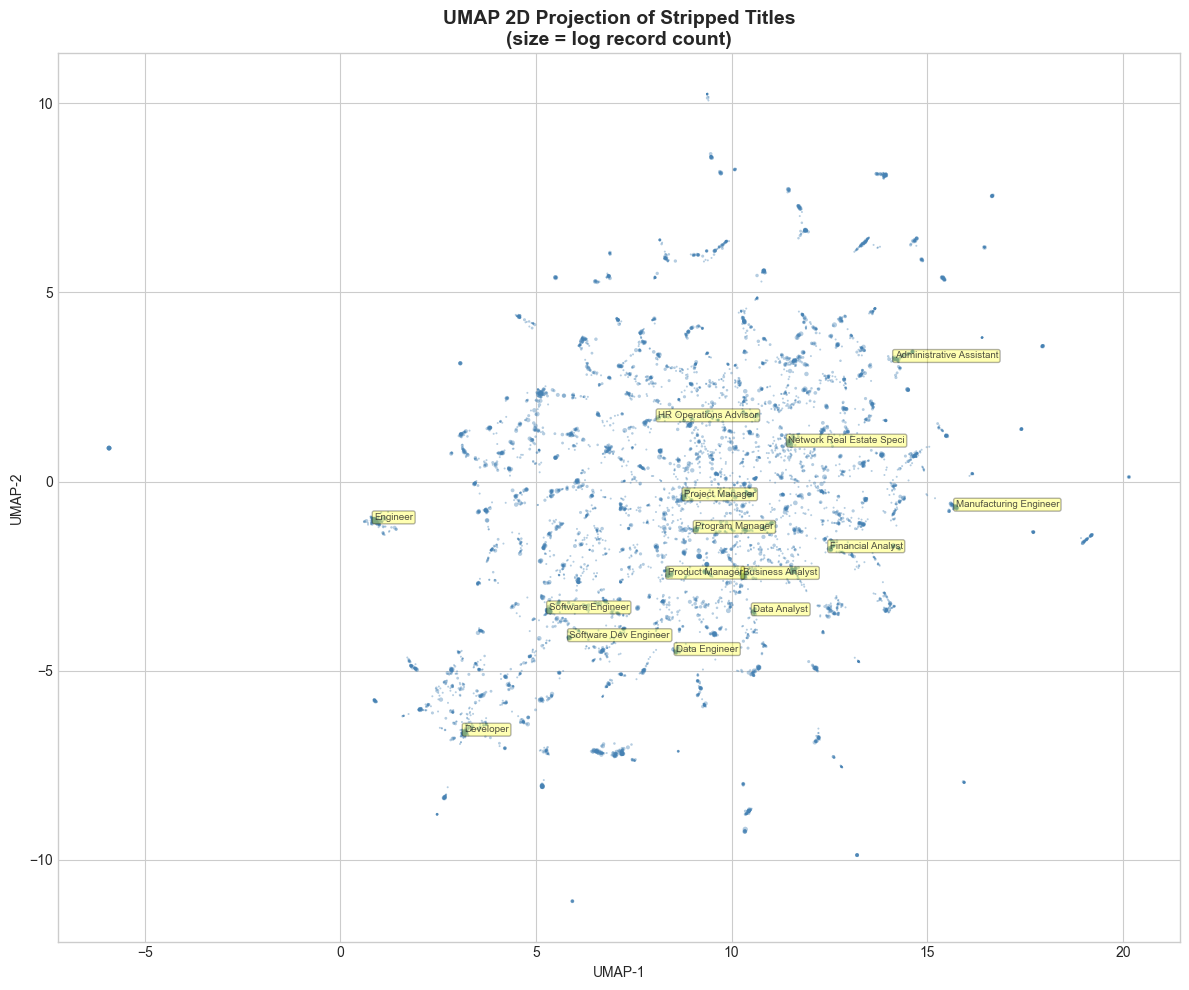


→ Clusters visible as dense regions. Next: K-Means to formalise them.


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — UMAP Dimensionality Reduction to 2D
#
# Reduce from ~5000 TF-IDF dimensions to 2D for:
#   1. Visualisation (scatter plot of title clusters)
#   2. Sanity check (similar titles should be near each other)
#
# Note: UMAP preserves local structure better than t-SNE
# and is faster on this data size.
# ═══════════════════════════════════════════════════════════════
import umap

print("Running UMAP (this may take 30-60 seconds)...")

# UMAP settings optimised for text clustering
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,       # local structure preservation
    min_dist=0.1,         # how tight clusters are
    metric='cosine',      # best for TF-IDF vectors
    random_state=42
)

# UMAP works with dense or sparse — sparse is fine
embedding_2d = reducer.fit_transform(X_combined)

title_volume['umap_x'] = embedding_2d[:, 0]
title_volume['umap_y'] = embedding_2d[:, 1]

print(f"\n✅ UMAP complete: {embedding_2d.shape}")
print(f"   X range: [{embedding_2d[:, 0].min():.1f}, {embedding_2d[:, 0].max():.1f}]")
print(f"   Y range: [{embedding_2d[:, 1].min():.1f}, {embedding_2d[:, 1].max():.1f}]")

# Quick sanity plot (uncolored)
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(
    title_volume['umap_x'], title_volume['umap_y'],
    s=np.log1p(title_volume['record_count']) * 3,  # size by volume
    alpha=0.4, c='steelblue', edgecolors='none'
)
ax.set_title('UMAP 2D Projection of Stripped Titles\n(size = log record count)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

# Label the top 15 highest-volume titles
for _, row in title_volume.head(15).iterrows():
    ax.annotate(row['stripped_title'][:25], 
                (row['umap_x'], row['umap_y']),
                fontsize=7, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n→ Clusters visible as dense regions. Next: K-Means to formalise them.")

TF-IDF matrix: 8,456 × 5,000 = 42,280,000 elements
⚠️  Matrix too large for dense conversion — running without sample_weight

Running K-Means for k = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]...
  k= 20 | inertia=     13612 | silhouette=0.098
  k= 20 | inertia=     13612 | silhouette=0.098
  k= 25 | inertia=     13142 | silhouette=0.125
  k= 25 | inertia=     13142 | silhouette=0.125
  k= 30 | inertia=     13038 | silhouette=0.112
  k= 30 | inertia=     13038 | silhouette=0.112
  k= 35 | inertia=     12668 | silhouette=0.136
  k= 35 | inertia=     12668 | silhouette=0.136
  k= 40 | inertia=     12469 | silhouette=0.135
  k= 40 | inertia=     12469 | silhouette=0.135
  k= 45 | inertia=     12282 | silhouette=0.136
  k= 45 | inertia=     12282 | silhouette=0.136
  k= 50 | inertia=     12065 | silhouette=0.150
  k= 50 | inertia=     12065 | silhouette=0.150
  k= 55 | inertia=     11897 | silhouette=0.146
  k= 55 | inertia=     11897 | silhouette=0.146
  k= 60 | inertia=     116

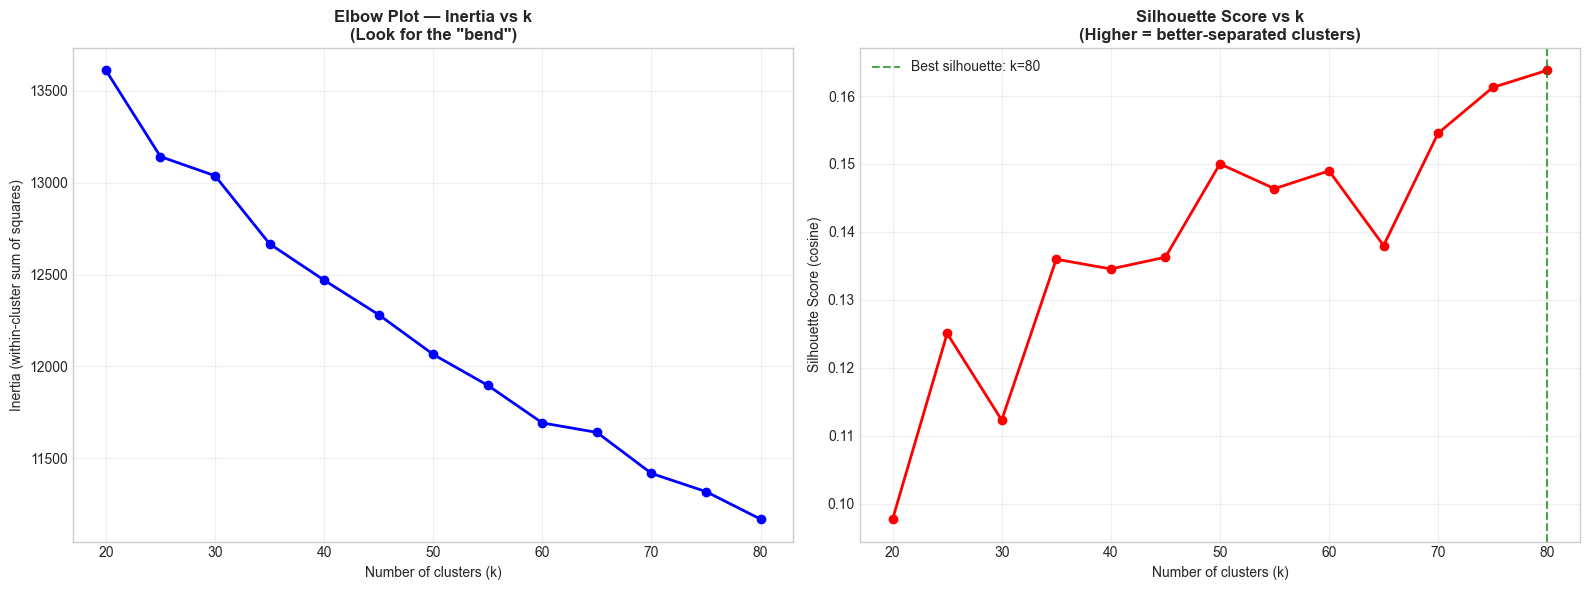


═══ ELBOW ANALYSIS ═══
Best silhouette score at k=80 (score=0.164)
Elbow detected at k≈25 (diminishing returns after this)

→ Set K = 80 (or 25 if you prefer tighter clusters)
→ Update the K variable in the next cell based on this result.


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Elbow Plot: Find Optimal k
#
# Don't assume k=50. Run K-means for k in [20, 80] and plot
# inertia to find the natural elbow point.
# Also plot silhouette score for each k as a secondary check.
# ═══════════════════════════════════════════════════════════════
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Check matrix size — if too large for dense, skip sample_weight
n_rows, n_cols = X_combined.shape
print(f"TF-IDF matrix: {n_rows:,} × {n_cols:,} = {n_rows * n_cols:,} elements")

if n_rows * n_cols > 25_000_000:
    print("⚠️  Matrix too large for dense conversion — running without sample_weight")
    X_fit = X_combined
    use_weights = False
else:
    X_fit = X_combined.toarray() if hasattr(X_combined, 'toarray') else X_combined
    use_weights = True
    print("✅ Converted to dense for weighted K-Means")

sample_weights = np.log1p(title_volume['record_count'].values)

# Run k-means for range of k values
k_range = range(20, 81, 5)
inertias = []
sil_scores = []

print(f"\nRunning K-Means for k = {list(k_range)}...")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    if use_weights:
        labels = km.fit_predict(X_fit, sample_weight=sample_weights)
    else:
        labels = km.fit_predict(X_fit)
    inertias.append(km.inertia_)
    
    # Silhouette on a sample (full computation is slow for large n)
    if n_rows > 5000:
        sample_idx = np.random.RandomState(42).choice(n_rows, 5000, replace=False)
        sil = silhouette_score(X_combined[sample_idx], labels[sample_idx], metric='cosine')
    else:
        sil = silhouette_score(X_combined, labels, metric='cosine')
    sil_scores.append(sil)
    print(f"  k={k:3d} | inertia={km.inertia_:10.0f} | silhouette={sil:.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Inertia (elbow)
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Plot — Inertia vs k\n(Look for the "bend")', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(k_range), sil_scores, 'ro-', linewidth=2, markersize=6)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score (cosine)')
axes[1].set_title('Silhouette Score vs k\n(Higher = better-separated clusters)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Mark best silhouette
best_k_sil = list(k_range)[np.argmax(sil_scores)]
axes[1].axvline(x=best_k_sil, color='green', linestyle='--', alpha=0.7, 
                label=f'Best silhouette: k={best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Compute rate of inertia decrease to find elbow programmatically
inertia_diffs = -np.diff(inertias)
inertia_ratios = inertia_diffs[1:] / inertia_diffs[:-1]  # diminishing returns ratio
elbow_idx = np.argmin(inertia_ratios) + 1  # where ratio drops most
elbow_k = list(k_range)[elbow_idx]

print(f"\n═══ ELBOW ANALYSIS ═══")
print(f"Best silhouette score at k={best_k_sil} (score={max(sil_scores):.3f})")
print(f"Elbow detected at k≈{elbow_k} (diminishing returns after this)")
print(f"\n→ Set K = {best_k_sil} (or {elbow_k} if you prefer tighter clusters)")
print(f"→ Update the K variable in the next cell based on this result.")

In [20]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — K-Means Clustering (k from elbow analysis)
#
# Cluster on the FULL TF-IDF vectors (not UMAP — UMAP is
# lossy and for visualisation only).
# Weight by record count so cluster centroids are pulled
# towards high-volume titles.
#
# K is set based on the elbow plot in the previous cell.
# Update this value after reviewing the elbow/silhouette output.
# ═══════════════════════════════════════════════════════════════
from sklearn.cluster import KMeans

# ── SET K HERE based on elbow plot output ──
K = 80  # k=80 gives finer clusters; catch-alls are a manual fix problem, not a k problem

print(f"Running K-Means with k={K} (from elbow analysis)...")

# Weight samples by log(record_count) so high-volume titles
# anchor cluster centroids
sample_weights = np.log1p(title_volume['record_count'].values)

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10,
    max_iter=300
)

# Convert to dense if feasible (avoids sparse + sample_weight edge cases)
n_rows, n_cols = X_combined.shape
if n_rows * n_cols > 25_000_000:
    print("  (sparse mode — no sample_weight due to matrix size)")
    clusters = kmeans.fit_predict(X_combined)
else:
    X_dense = X_combined.toarray() if hasattr(X_combined, 'toarray') else X_combined
    clusters = kmeans.fit_predict(X_dense, sample_weight=sample_weights)

title_volume['cluster_id'] = clusters

print(f"\n✅ K-Means complete: {K} clusters")
print(f"   Inertia: {kmeans.inertia_:.0f}")

# Cluster size distribution
cluster_sizes = title_volume.groupby('cluster_id').agg(
    n_titles=('stripped_title', 'count'),
    total_records=('record_count', 'sum'),
    top_title=('stripped_title', lambda x: x.iloc[0])  # most common in group
).sort_values('total_records', ascending=False)

print(f"\n── Cluster Size Distribution: ──")
print(f"{'Cluster':<10} {'Titles':<10} {'Records':<10} {'Top Title'}")
print("─"*70)
for cid, row in cluster_sizes.head(20).iterrows():
    # Get actual top title by volume in this cluster
    cluster_titles = title_volume[title_volume['cluster_id'] == cid].sort_values('record_count', ascending=False)
    top = cluster_titles.iloc[0]['stripped_title']
    print(f"{cid:<10} {row['n_titles']:<10} {row['total_records']:<10,} {top[:45]}")

print(f"\n── Size stats: ──")
print(f"  Largest cluster:  {cluster_sizes['total_records'].max():,} records")
print(f"  Smallest cluster: {cluster_sizes['total_records'].min():,} records")
print(f"  Median cluster:   {cluster_sizes['total_records'].median():,.0f} records")
print(f"  Clusters with >= 200 records: {(cluster_sizes['total_records'] >= 200).sum()}")
print(f"  Clusters with < 100 records:  {(cluster_sizes['total_records'] < 100).sum()}")

Running K-Means with k=80 (from elbow analysis)...
  (sparse mode — no sample_weight due to matrix size)

✅ K-Means complete: 80 clusters
   Inertia: 11169

── Cluster Size Distribution: ──
Cluster    Titles     Records    Top Title
──────────────────────────────────────────────────────────────────────
20         498        3,688      Engineer
38         1043       3,119      Unit Supervisor
15         227        2,594      Software Engineer
35         180        2,431      Program Manager
39         208        1,634      Project Manager
3          361        1,479      Network Real Estate Specialist / Developer -
51         212        1,094      Project Coordinator
62         262        1,085      Developer
13         106        1,030      Administrative Assistant
6          125        992        Business Analyst
12         110        991        Java Back End Developer IV (APAC-IND)
32         108        905        Engineer Quality
1          280        869        Logistics Analyst
59

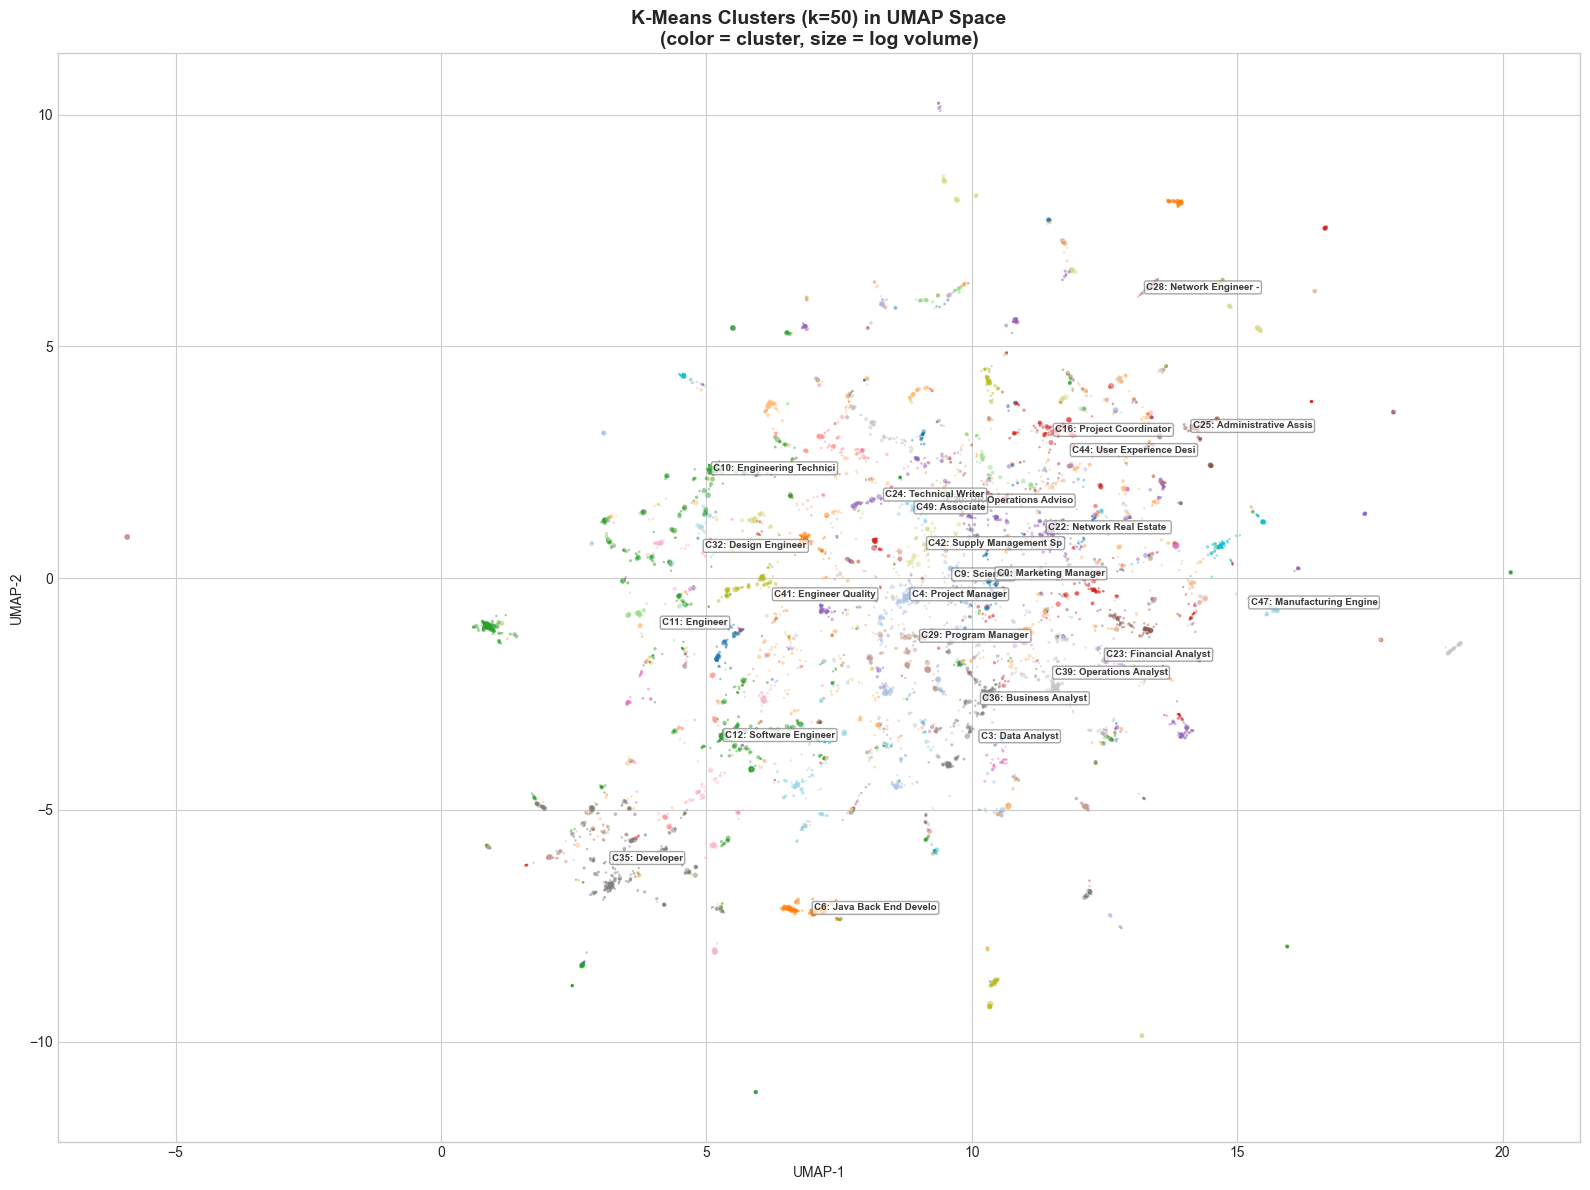


→ Well-separated clusters = good. Overlapping clusters may need merging.
→ Isolated outlier dots = thin titles that got their own cluster.


In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — Visualise 2D Scatter with Cluster Colors
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 12))

# Color by cluster
scatter = ax.scatter(
    title_volume['umap_x'], title_volume['umap_y'],
    c=title_volume['cluster_id'],
    cmap='tab20',
    s=np.log1p(title_volume['record_count']) * 4,
    alpha=0.5,
    edgecolors='none'
)

# Label cluster centroids (median position in UMAP space)
centroids = title_volume.groupby('cluster_id').agg(
    cx=('umap_x', 'median'),
    cy=('umap_y', 'median'),
    total_records=('record_count', 'sum')
).sort_values('total_records', ascending=False)

# Label top 25 clusters by volume
for cid, row in centroids.head(25).iterrows():
    # Get the highest-volume title in this cluster as label
    top_title = title_volume[title_volume['cluster_id'] == cid].sort_values(
        'record_count', ascending=False
    ).iloc[0]['stripped_title']
    label = f"C{cid}: {top_title[:20]}"
    ax.annotate(label, (row['cx'], row['cy']),
                fontsize=7, fontweight='bold', alpha=0.9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='gray'))

ax.set_title(f'K-Means Clusters (k={K}) in UMAP Space\n(color = cluster, size = log volume)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

plt.tight_layout()
plt.show()

print("\n→ Well-separated clusters = good. Overlapping clusters may need merging.")
print("→ Isolated outlier dots = thin titles that got their own cluster.")

In [21]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Inspect Every Cluster: Titles & Coherence
#
# For each cluster, show:
#   - Top 10 titles by volume
#   - Total records in cluster
#   - Coherence: do titles make semantic sense together?
# Flag any clusters that look incoherent for manual fix.
# ═══════════════════════════════════════════════════════════════

print("═"*70)
print(f"ALL {K} CLUSTERS — Inspection")
print("═"*70)

cluster_order = title_volume.groupby('cluster_id')['record_count'].sum().sort_values(ascending=False).index

cluster_labels = {}  # Will store our chosen label for each cluster

for rank, cid in enumerate(cluster_order, 1):
    cluster_data = title_volume[title_volume['cluster_id'] == cid].sort_values('record_count', ascending=False)
    total = cluster_data['record_count'].sum()
    n_titles = len(cluster_data)
    
    # Auto-label: use the highest-volume title in the cluster
    label = cluster_data.iloc[0]['stripped_title']
    cluster_labels[cid] = label
    
    print(f"\n{'─'*70}")
    print(f"CLUSTER {cid} (rank #{rank}) — {total:,} records, {n_titles} titles")
    print(f"AUTO-LABEL: '{label}'")
    print(f"{'─'*70}")
    
    for i, (_, row) in enumerate(cluster_data.head(10).iterrows(), 1):
        pct = row['record_count'] / total * 100
        print(f"  {i:2d}. {row['stripped_title'][:55]:<55} {row['record_count']:>5,} ({pct:>5.1f}%)")
    
    if n_titles > 10:
        print(f"  ... +{n_titles - 10} more titles")

══════════════════════════════════════════════════════════════════════
ALL 80 CLUSTERS — Inspection
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
CLUSTER 20 (rank #1) — 3,688 records, 498 titles
AUTO-LABEL: 'Engineer'
──────────────────────────────────────────────────────────────────────
   1. Engineer                                                  374 ( 10.1%)
   2. Data Engineer                                             222 (  6.0%)
   3. Engineer-RF -                                             186 (  5.0%)
   4. OSP Engineer -                                            158 (  4.3%)
   5. Engineer- Construction -                                  156 (  4.2%)
   6. Engineer-Transport -                                      156 (  4.2%)
   7. Electrical Engineer                                       105 (  2.8%)
   8. Network Engineer -                                        103 (  2.8%

In [28]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Manual Reassignment & Cluster Naming
#
# Based on Cell 9 inspection, fix misplacements and assign
# clean human-readable names to each cluster.
#
# Strategy:
#   - If a cluster is coherent → keep, assign clean name
#   - If a cluster mixes unrelated titles → split or reassign
#   - If two clusters are basically the same role → merge
#   - Thin clusters (< 50 records) → merge into nearest large cluster
#
# After this cell: every cluster_id has a final `cluster_name`.
# ═══════════════════════════════════════════════════════════════

# ── STEP 1: Start with auto-labels from Cell 9 ──
# cluster_labels dict already populated: {cluster_id: 'top_title'}

# ── STEP 2: Define manual overrides ──
# Format: cluster_id → clean human-readable name

MANUAL_NAMES = {
    20: 'Engineering - General',
    38: 'Operations - General',
    15: 'Software Engineer',
    35: 'Program Manager',
    39: 'Project Manager',
    3:  'Specialist - General',
    51: 'Project Coordinator',
    62: 'Developer',
    13: 'Administrative Assistant',
    6:  'Business Analyst',
    12: 'Java Developer (India)',
    32: 'QA Engineer',
    1:  'Logistics Analyst',
    59: 'Engineering Technician',
    25: 'HR Operations',
    49: 'UI/UX Designer',
    57: 'Product Manager',
    58: 'Data Analyst',
    50: 'Marketing Manager',
    63: 'Associate - General',
    67: 'Design Engineer',
    65: 'Manufacturing Engineer',
    2:  'Finance & Accounting',
    72: 'Scientist',
    34: 'Supply Chain',
    7:  'Support Engineer',
    37: 'Legal Consultant',
    19: 'Technical Writer',
    17: 'Content Strategist',
    52: 'Business Systems Analyst',
    69: 'Mechanical Engineer',
    28: 'Systems Administrator',
    56: 'IT Analyst',
    48: 'Process Development Engineer',
    78: 'Customer Service',
    23: 'ERP Consultant',
    53: 'Architect',
    61: 'Recruiter',
    66: 'Database Administrator',
    8:  'DevOps Engineer',
    79: 'Healthcare / Clinical',
    27: 'Business Intelligence Engineer',
    14: 'Graphic Designer',
    75: 'Operations Analyst',
    60: 'Automation Engineer',
    44: 'Trainer',
    24: 'Scrum Master',
    47: 'Statistician',
    0:  'Sales / Account Manager',
    71: 'Technical Artist',
    11: 'India - Acceleration Center',
}

# ── STEP 3: Define merges ──
# Format: {source_cluster_id: target_cluster_id}

CLUSTER_MERGES = {
    # Software family
    46: 15,   # Software Development Engineer (rank 30, ID 46) → Software Engineer
    4:  15,   # Software Application Engr (rank 48, ID 4) → Software Engineer
    5:  15,   # Level 7 noise (rank 44, ID 5) → Software Engineer

    # Developer family
    45: 62,   # Java Back End Developer (rank 47, ID 45) → Developer
    73: 62,   # Java Developer (rank 54, ID 73) → Developer
    70: 62,   # Backend Developer (rank 74, ID 70) → Developer
    33: 62,   # ETL Developer (rank 79, ID 33) → Developer
    64: 62,   # Android Developer (rank 72, ID 64) → Developer
    10: 62,   # Applications Developer (rank 37, ID 10) → Developer
    21: 62,   # Full Stack Developer (rank 36, ID 21) → Developer

    # QA family
    76: 32,   # Quality/Test Engineer (rank 38, ID 76) → QA Engineer
    68: 32,   # Manual QA (rank 69, ID 68) → QA Engineer

    # HR family
    30: 25,   # HR and Talent Acquisition (rank 64, ID 30) → HR Operations
    42: 25,   # Human Resources (rank 71, ID 42) → HR Operations
    29: 25,   # HR Coordinator (rank 77, ID 29) → HR Operations

    # Finance family
    40: 2,    # Financial Analyst (rank 27, ID 40) → Finance & Accounting
    11: 2,    # AP Accounting Assistant (rank 39, ID 11) → Finance & Accounting
    36: 2,    # Accountant (rank 55, ID 36) → Finance & Accounting

    # Supply chain family
    43: 34,   # Supply Chain Analyst (rank 29, ID 43) → Supply Chain
    77: 34,   # Buyer/Purchasing (rank 45, ID 77) → Supply Chain

    # Architecture family
    26: 53,   # Solution Architect (rank 67, ID 26) → Architect

    # Cloud/DevOps
    54: 8,    # Cloud Engineer (rank 62, ID 54) → DevOps Engineer

    # UX family
    41: 49,   # User Experience Designer (rank 46, ID 41) → UI/UX Designer

    # Mechanical Engineering duplicate
    18: 69,   # Engineering/Technology Mechanical II (rank 66, ID 18) → Mechanical Engineer

    # Program/Project coordination
    9:  51,   # Program Coordinator (rank 75, ID 9) → Project Coordinator

    # ERP family
    55: 23,   # Oracle Cloud Technical (rank 61, ID 55) → ERP Consultant

    # Noise → catch-all
    74: 38,   # MSP|IND noise → Operations - General
    31: 38,   # Title Exception garbage → Operations - General
    22: 38,   # United States geographic noise → Operations - General
    16: 59,   # Validation Engineer → Engineering Technician
}

# ── STEP 4: Apply merges ──
title_volume['cluster_final'] = title_volume['cluster_id'].map(
    lambda x: CLUSTER_MERGES.get(x, x)
)

# ── STEP 5: Apply names ──
# First apply manual overrides, then fall back to auto-labels
# final_labels is keyed by cluster_id — since cluster_final maps merged→target,
# the .map() call correctly resolves merged clusters to the target's label.
final_labels = {**cluster_labels, **MANUAL_NAMES}
title_volume['cluster_name'] = title_volume['cluster_final'].map(final_labels)

# ── STEP 6: Summary ──
final_cluster_counts = title_volume.groupby('cluster_name').agg(
    n_titles=('stripped_title', 'count'),
    total_records=('record_count', 'sum')
).sort_values('total_records', ascending=False)

print("═"*70)
print(f"FINAL CLUSTERS — {len(final_cluster_counts)} groups")
print("═"*70)
print(f"\n{'Rank':<6} {'Cluster Name':<45} {'Titles':<8} {'Records':<10} {'%'}")
print("─"*75)

total_records = final_cluster_counts['total_records'].sum()
for rank, (name, row) in enumerate(final_cluster_counts.iterrows(), 1):
    pct = row['total_records'] / total_records * 100
    print(f"{rank:<6} {name[:44]:<45} {row['n_titles']:<8} {row['total_records']:<10,} {pct:.1f}%")

print(f"\n── Stats: ──")
print(f"Total clusters: {len(final_cluster_counts)}")
print(f"Clusters with >= 200 records: {(final_cluster_counts['total_records'] >= 200).sum()}")
print(f"Clusters with < 100 records:  {(final_cluster_counts['total_records'] < 100).sum()}")
print(f"\n→ After reviewing, update MANUAL_NAMES and CLUSTER_MERGES above and re-run.")

══════════════════════════════════════════════════════════════════════
FINAL CLUSTERS — 50 groups
══════════════════════════════════════════════════════════════════════

Rank   Cluster Name                                  Titles   Records    %
───────────────────────────────────────────────────────────────────────────
1      Operations - General                          1211     3,786      9.0%
2      Engineering - General                         498      3,688      8.8%
3      Software Engineer                             426      3,510      8.4%
4      Program Manager                               180      2,431      5.8%
5      Developer                                     546      2,377      5.7%
6      Project Manager                               208      1,634      3.9%
7      Finance & Accounting                          433      1,508      3.6%
8      Specialist - General                          361      1,479      3.5%
9      QA Engineer                                   22

In [30]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — Cluster Quality Check: Silhouette + Region Split
#
# 1. Silhouette score — are clusters well-separated?
# 2. Per-region coverage — do all regions have viable clusters?
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import silhouette_score, silhouette_samples

# Silhouette on final clusters
final_cluster_ids = title_volume['cluster_final'].values
sil_score = silhouette_score(X_combined, final_cluster_ids, metric='cosine', sample_size=min(5000, len(title_volume)))

print("═"*70)
print("CLUSTER QUALITY METRICS")
print("═"*70)
print(f"\nOverall silhouette score: {sil_score:.3f}")
print(f"  (> 0.3 = reasonable structure, > 0.5 = strong clusters)")

# Per-cluster silhouette
sil_samples = silhouette_samples(X_combined, final_cluster_ids, metric='cosine')
title_volume['silhouette'] = sil_samples

cluster_sil = title_volume.groupby('cluster_name')['silhouette'].mean().sort_values()
print(f"\n── Worst 10 clusters (lowest silhouette — most incoherent): ──")
for name, score in cluster_sil.head(10).items():
    print(f"  {score:.3f}  {name[:50]}")

print(f"\n── Best 10 clusters (highest silhouette — most coherent): ──")
for name, score in cluster_sil.tail(10).items():
    print(f"  {score:.3f}  {name[:50]}")

# ── Per-region coverage ──
print(f"\n{'═'*70}")
print("PER-REGION CLUSTER COVERAGE")
print("═"*70)

# Map clusters back to main df
raw_to_cluster = dict(zip(title_volume['stripped_title'], title_volume['cluster_name']))
df['role_cluster'] = df['title_stripped'].map(raw_to_cluster)

for region in ['US', 'IN', 'LATAM']:
    region_data = df[df['region'] == region]
    region_clusters = region_data['role_cluster'].value_counts()
    viable = (region_clusters >= 40).sum()
    total = len(region_clusters)
    coverage = region_clusters[region_clusters >= 40].sum() / len(region_data) * 100
    
    print(f"\n  {region}: {len(region_data):,} records → {total} clusters, {viable} viable (≥40 records)")
    print(f"       Coverage of viable clusters: {coverage:.1f}%")
    print(f"       Top 5: {', '.join(region_clusters.head(5).index.tolist())}")

══════════════════════════════════════════════════════════════════════
CLUSTER QUALITY METRICS
══════════════════════════════════════════════════════════════════════

Overall silhouette score: 0.120
  (> 0.3 = reasonable structure, > 0.5 = strong clusters)

── Worst 10 clusters (lowest silhouette — most incoherent): ──
  -0.073  HR Operations
  -0.073  Operations - General
  -0.065  Finance & Accounting
  0.012  Supply Chain
  0.021  Software Engineer
  0.039  QA Engineer
  0.059  Logistics Analyst
  0.065  UI/UX Designer
  0.075  Engineering - General
  0.096  ERP Consultant

── Best 10 clusters (highest silhouette — most coherent): ──
  0.345  Administrative Assistant
  0.351  Operations Analyst
  0.356  Business Systems Analyst
  0.408  Manufacturing Engineer
  0.427  Healthcare / Clinical
  0.444  Scientist
  0.466  Business Intelligence Engineer
  0.551  Scrum Master
  0.559  Graphic Designer
  0.562  Recruiter

═════════════════════════════════════════════════════════════════════

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — Export: title_to_cluster.pkl
#
# Final output: a mapping from EVERY raw title to its cluster.
# This gets joined back onto clean_42k_v1.pkl as role_cluster.
# ═══════════════════════════════════════════════════════════════

# Build the complete mapping: raw_title → cluster_name
# (through stripped_title as intermediate)
title_to_cluster = title_df.copy()
title_to_cluster['stripped_title'] = title_to_cluster['raw_title'].apply(strip_seniority)
title_to_cluster['role_cluster'] = title_to_cluster['stripped_title'].map(raw_to_cluster)

# Fallback: assign unmapped titles (empty stripped strings, edge cases) to 'Other'
title_to_cluster.loc[
    title_to_cluster['role_cluster'].isna(), 'role_cluster'
] = 'Other'

# Verify no nulls
nulls = title_to_cluster['role_cluster'].isna().sum()
if nulls > 0:
    print(f"⚠️  {nulls} raw titles have no cluster assignment!")
    print(title_to_cluster[title_to_cluster['role_cluster'].isna()].head(10))
else:
    print(f"✅ All {len(title_to_cluster):,} raw titles mapped to a cluster.")

# Save as pickle
mapping_path = os.path.join(data_dir, 'title_to_cluster.pkl')
title_to_cluster[['raw_title', 'stripped_title', 'role_cluster']].to_pickle(mapping_path)

print(f"\n✅ Saved: {mapping_path}")
print(f"   Shape: {title_to_cluster.shape}")
print(f"   Unique raw titles:     {title_to_cluster['raw_title'].nunique():,}")
print(f"   Unique stripped titles: {title_to_cluster['stripped_title'].nunique():,}")
print(f"   Unique clusters:        {title_to_cluster['role_cluster'].nunique()}")

# Also update the main df and re-export with role_cluster
df['role_cluster'] = df['title'].map(
    dict(zip(title_to_cluster['raw_title'], title_to_cluster['role_cluster']))
)

# Show final cluster distribution
print(f"\n── Final Cluster Distribution (all 42k records): ──")
cluster_dist = df['role_cluster'].value_counts()
print(f"{'Rank':<6} {'Cluster':<45} {'Records':<10} {'%'}")
print("─"*65)
for rank, (cluster, count) in enumerate(cluster_dist.head(30).items(), 1):
    pct = count / len(df) * 100
    print(f"{rank:<6} {cluster[:44]:<45} {count:<10,} {pct:.1f}%")

if len(cluster_dist) > 30:
    remaining = cluster_dist.iloc[30:].sum()
    print(f"{'...':<6} {'(remaining clusters)':<45} {remaining:<10,} {remaining/len(df)*100:.1f}%")

print(f"\n{'═'*70}")
print("EXPORT COMPLETE")
print("═"*70)
print(f"\nFiles saved:")
print(f"  1. {mapping_path}")
print(f"     → title_to_cluster mapping (join key: raw_title)")
print(f"\nUsage in next notebook:")
print(f"  mapping = pd.read_pickle('data/title_to_cluster.pkl')")
print(f"  df['role_cluster'] = df['title'].map(dict(zip(mapping['raw_title'], mapping['role_cluster'])))")
print(f"\n→ Ready for 03_forecasting.ipynb")

✅ All 11,416 raw titles mapped to a cluster.

✅ Saved: c:\Users\serveradmin\Desktop\resume-processing-system\data\title_to_cluster.pkl
   Shape: (11416, 3)
   Unique raw titles:     11,416
   Unique stripped titles: 8,456
   Unique clusters:        50

── Final Cluster Distribution (all 42k records): ──
Rank   Cluster                                       Records    %
─────────────────────────────────────────────────────────────────
1      Operations - General                          3,786      9.0%
2      Engineering - General                         3,688      8.8%
3      Software Engineer                             3,510      8.4%
4      Program Manager                               2,431      5.8%
5      Developer                                     2,377      5.7%
6      Project Manager                               1,634      3.9%
7      Finance & Accounting                          1,508      3.6%
8      Specialist - General                          1,479      3.5%
9      QA E

: 